In [1]:
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from tqdm import tqdm
import sys
sys.path.append("..")

In [2]:
%load_ext autoreload
%autoreload 2
import strings

In [3]:
nside = 128
lmax = 3 * nside - 1

In [4]:
l, cl = strings.compute_cls(G_mu=8.9*1e-4, P=1, N_k=10, l_max=lmax)
nl = np.ones(len(l))/(l**4 * 1e7)

Computing C_l:  60%|█████▉    | 229/382 [00:01<00:00, 178.05ℓ/s]/Users/antoidicherianlonappan/Workspace/cosmic_strings/notebooks/../strings.py:71: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  inner, _ = quad(inner_integrand,
Computing C_l: 100%|██████████| 382/382 [00:02<00:00, 173.41ℓ/s]


In [5]:
cl_sim = []
for i in tqdm(range(25)):
    slm = hp.synalm(cl, lmax=3*128-1, new=True)
    nlm = hp.synalm(nl, lmax=3*128-1, new=True)
    alm = slm + nlm
    cl_sim.append(hp.alm2cl(alm)[2:lmax+1])
cl_sim = np.array(cl_sim)

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:00<00:00, 268.31it/s]


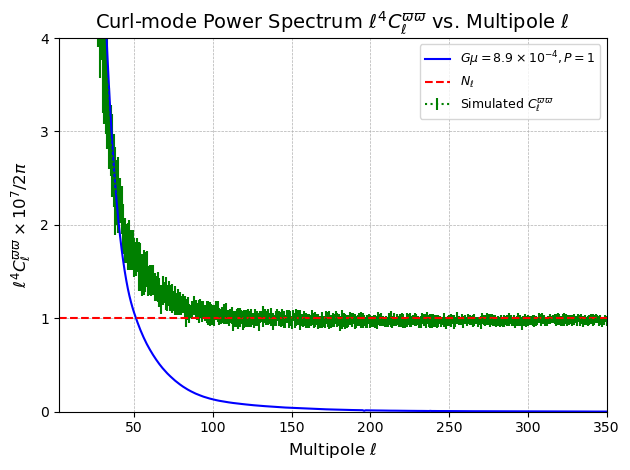

In [6]:
plt.errorbar(l, l**4 * np.mean(cl_sim, axis=0) * 1e7, yerr=l**4 * np.std(cl_sim, axis=0) * 1e7, 
             label='Simulated $C_\\ell^{\\varpi\\varpi}$', color='green', linestyle=':', linewidth=1.5)
plt.plot(l, l**4 * cl * 1e7, label=r'$G\mu = 8.9 \times 10^{-4}, P = 1$', color='blue', linewidth=1.5)
plt.plot(l, np.ones(len(l)), label=r'$N_\ell$', color='red', linestyle='--', linewidth=1.5)
plt.title(r'Curl-mode Power Spectrum $\ell^4 C_\ell^{\varpi\varpi}$ vs. Multipole $\ell$', fontsize=14)
plt.xlabel(r'Multipole $\ell$', fontsize=12)
plt.ylabel(r'$\ell^4 C_\ell^{\varpi\varpi} \times 10^7 / 2\pi$', fontsize=12)
plt.ylim(0, 4)
plt.xlim(2, 350)
plt.yticks(np.arange(0, 4.1, 1))
plt.legend(fontsize=9, loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()

In [7]:
class Likelihood:
    def __init__(self, P=None, G_mu=None, N_k=30, lmax=500, data=None, std=None,nl=None):
        if P is None:
            Pconst = False
        else:
            Pconst = True
            assert G_mu is not None, "G_mu must be provided if P is constant"
        self.Pconst = Pconst
        self.P = P
        self.G_mu = G_mu
        self.N_k = N_k
        self.lmax = lmax
        if Pconst:
            self.l, self.CL = strings.compute_cls(G_mu=G_mu, P=P, N_k=N_k, l_max=lmax)
        else:
            self.l, self.CL = None, None
        self.data = data
        self.std = std
        self.nl = nl

    def theory(self, G_mu, P=None):
        if self.Pconst:
            diff = self.G_mu/G_mu
            l,cl = self.l,diff**2 * self.CL
        else:
            assert P is not None, "P must be provided for non-constant P"
            l, cl = strings.compute_cls(G_mu=G_mu, P=P, N_k=self.N_k, l_max=self.lmax)
        
        return l, cl+self.nl
    
    def chi2(self, theta):
        if self.Pconst:
            G_mu = theta
            l, cl = self.theory(G_mu)
        else:
            G_mu, P = theta
            l, cl = self.theory(G_mu, P)

        diff = ( (l**4 * self.data)-(l**4 * cl))[20:100]
        std = self.std[20:100]
        ratio = diff / std
        ratio[np.isnan(ratio)] = 0
        ratio[np.isinf(ratio)] = 0
        chi2_val = np.sum(ratio**2)
        return chi2_val

In [8]:
gmu = np.arange(6*1e-4, 2.01*1e-3, 0.01*1e-3)

In [9]:
lh = Likelihood(P=1, G_mu=8*1e-4, N_k=10, lmax=lmax, data=np.mean(cl_sim, axis=0), std=np.std(cl_sim, axis=0),nl=nl)

Computing C_l: 100%|██████████| 382/382 [00:02<00:00, 187.88ℓ/s]


In [10]:
chi2_values = [ lh.chi2(g) for g in tqdm(gmu) ]

  0%|          | 0/141 [00:00<?, ?it/s]

100%|██████████| 141/141 [00:00<00:00, 71390.25it/s]


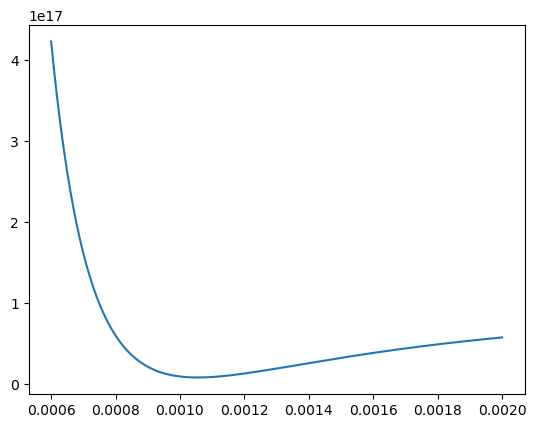

In [11]:
plt.plot(gmu, chi2_values)